In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [52]:
# Dataset name
file_name = "PS_2026.04.27_17.30.53.csv"
# Read the file
df = pd.read_csv(file_name, comment="#")
#filter out those planets which are not confirmed, because there is not a table that contains only confirmed planets
df_final = df[df["soltype"] == "Published Confirmed"].copy()
df_final = df_final[df_final["default_flag"] == 1]
df_final = df_final[df_final["pl_controv_flag"] == 0]
# Print final usable sample size
print("Final rows:", len(df_final))
# Preview cleaned dataset
df_final.head()

Final rows: 6152


,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,1,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-08,2023-09-19
4,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06
6,14 And b,14 And,1,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,Published Confirmed,0,...,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826,2023-09-19,2023-08,2023-09-19
17,14 Her b,14 Her,1,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,Published Confirmed,0,...,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351,2026-03-26,2025-07,2026-03-26
20,16 Cyg B b,16 Cyg B,1,3,1,Radial Velocity,1996.0,Multiple Observatories,Published Confirmed,0,...,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603,2018-09-04,2017-03,2018-09-06


In [53]:
# Display all available column names after data cleaning. This helps identify which astrophysical variables can be used
print(df_final.columns.tolist())

['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 'st_metlim', 'st_metratio', 'st_logg', 'st

In [54]:
# Select candidate features for clustering analysis
features = [
    "pl_rade", "pl_bmasse", "pl_eqt", "pl_orbsmax", "pl_orbper",
    "pl_insol", "pl_orbeccen", "st_teff", "st_mass", "st_rad"
]

print("Total rows:", len(df_final))
# Count missing values for each selected feature
print(df_final[features].isna().sum())

Total rows: 6152
pl_rade        1556
pl_bmasse      3122
pl_eqt         4528
pl_orbsmax     2409
pl_orbper       359
pl_insol       5312
pl_orbeccen    3645
st_teff         736
st_mass         879
st_rad          798
dtype: int64


In [55]:
# Select a smaller set of core features with relatively better data availability
features_core = [
    "pl_rade",
    "pl_bmasse",
    "pl_orbsmax",
    "pl_orbper",
    "st_teff",
    "st_mass"
]
# Keep only rows where all selected core features are available
data_ml = df_final[features_core].dropna().copy()

# Print final usable sample size for machine learning analysis
print("Rows after dropna:", len(data_ml))

Rows after dropna: 1143


In [56]:
#Adding density proxy as an additional feature
data_ml["density_proxy"] = data_ml["pl_bmasse"] / (data_ml["pl_rade"]**3)

In [57]:
# These are transformed using log10 to reduce skewness
# and improve clustering performance
log_cols = [
    "pl_rade",
    "pl_bmasse",
    "pl_orbsmax",
    "pl_orbper",
    "st_teff",
    "st_mass",
    "density_proxy"
]

for col in log_cols:
    data_ml = data_ml[data_ml[col] > 0]
    data_ml["log_" + col] = np.log10(data_ml[col])

In [58]:
# Feature matrix used for clustering
# Use log-transformed variables instead of raw values as the initial version has already showed raw values performs not well
X = data_ml[
[
"log_pl_rade",
"log_pl_bmasse",
"log_pl_orbsmax",
"log_pl_orbper",
"log_st_teff",
"log_st_mass",
"log_density_proxy"
]]

In [59]:
# Standardize all features to mean = 0 and standard deviation = 1
# This prevents variables with large numeric scales from dominating clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [60]:
# Test multiple values of k. Using silhouette score to evaluate clustering quality
k_values = range(2, 8)
scores = []

for k in k_values:
    # Initialize KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fit model and assign cluster labels
    labels = kmeans.fit_predict(X_scaled)
    # Compute silhouette score
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.3483
k=3, silhouette=0.3475
k=4, silhouette=0.3607
k=5, silhouette=0.3141
k=6, silhouette=0.3076
k=7, silhouette=0.2716


In [61]:
# Select best-performing k based on silhouette score
best_k = 4
# Fit final KMeans model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
# Generate final cluster labels
labels = kmeans.fit_predict(X_scaled)
# Save cluster assignments into dataframe
data_ml["cluster"] = labels

print(data_ml["cluster"].value_counts().sort_index())

cluster
0    294
1    568
2    148
3    133
Name: count, dtype: int64


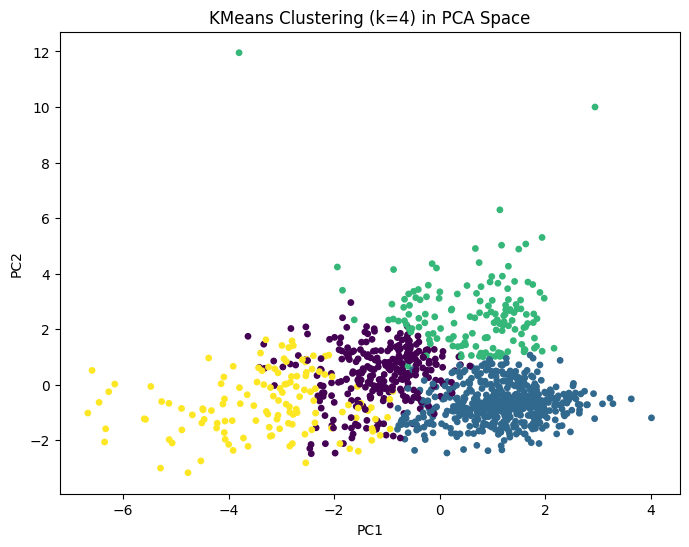

In [62]:
# Apply PCA to reduce the standardized feature space to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Store the first two principal components in the dataframe
data_ml["PC1"] = X_pca[:,0]
data_ml["PC2"] = X_pca[:,1]
# Plot the KMeans clustering result in PCA space
plt.figure(figsize=(8,6))
plt.scatter(data_ml["PC1"], data_ml["PC2"], c=data_ml["cluster"], s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering (k=4) in PCA Space")
plt.show()

In [63]:
# Compute the mean physical properties of each cluster
# This helps interpret what type of planets each cluster may represent
print(
data_ml.groupby("cluster")[
[
"pl_rade",
"pl_bmasse",
"pl_orbsmax",
"pl_orbper",
"density_proxy",
"st_mass"
]
].mean()
)

           pl_rade   pl_bmasse  pl_orbsmax     pl_orbper  density_proxy  \
cluster                                                                   
0         2.498852   28.177359    0.083041     10.422983       1.728373   
1        13.288011  556.881047    0.052238      4.425634       0.277366   
2         8.137280  600.673949    2.227235  55258.198710       3.797302   
3         2.873477   75.393209    0.044124      6.305993       8.616688   

          st_mass  
cluster            
0        0.912601  
1        1.105156  
2        1.046252  
3        0.411212  


In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [65]:
# I decided to use Random Forest to evaluate feature importance 
# and see whether the selected features are effective for separating the clusters
# Split the dataset into training and testing sets
# X = input features, cluster labels are used as target classes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    data_ml["cluster"],
    test_size=0.25,
    random_state=42,
    stratify=data_ml["cluster"]
)
# Train a Random Forest classifier to predict KMeans cluster labels
# This is used to estimate which variables are most useful for separating the discovered clusters
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42
)

rf.fit(X_train, y_train)
# Predict cluster labels on test data
pred = rf.predict(X_test)
# Classification accuracy: high accuracy means clusters are well explained by the selected features
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.972027972027972


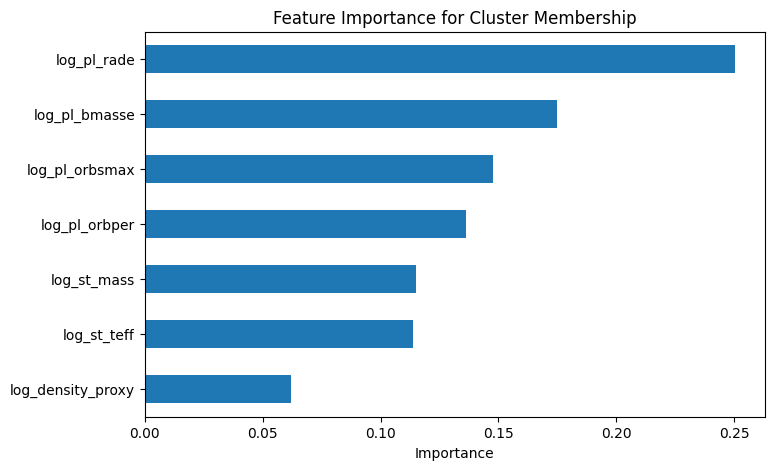

log_pl_rade          0.250535
log_pl_bmasse        0.174759
log_pl_orbsmax       0.147577
log_pl_orbper        0.136070
log_st_mass          0.115168
log_st_teff          0.113748
log_density_proxy    0.062143
dtype: float64


In [66]:
# Extract feature importance scores from the trained Random Forest model
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)
# Plot feature importance as a horizontal bar chart
plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Feature Importance for Cluster Membership")
plt.show()

print(importance.sort_values(ascending=False))

In [67]:
# Final selected feature set for the optimized KMeans model
# Orbital period is removed because it is strongly related to semi-major axis
# through Kepler's third law, so keeping both would add redundant information
X_final = data_ml[
[
"log_pl_rade",
"log_pl_bmasse",
"log_density_proxy",
"log_pl_orbsmax",
"log_st_mass",
"log_st_teff"
]
]

In [68]:
# Standardize the final selected features before clustering
scaler = StandardScaler()
Xf_scaled = scaler.fit_transform(X_final)

k=2, silhouette=0.3798
k=3, silhouette=0.3624
k=4, silhouette=0.3492
k=5, silhouette=0.3336
k=6, silhouette=0.3021
k=7, silhouette=0.2723
k=8, silhouette=0.2802
k=9, silhouette=0.2543
k=10, silhouette=0.2743
k=11, silhouette=0.2749
k=12, silhouette=0.2628
k=13, silhouette=0.2460
k=14, silhouette=0.2360


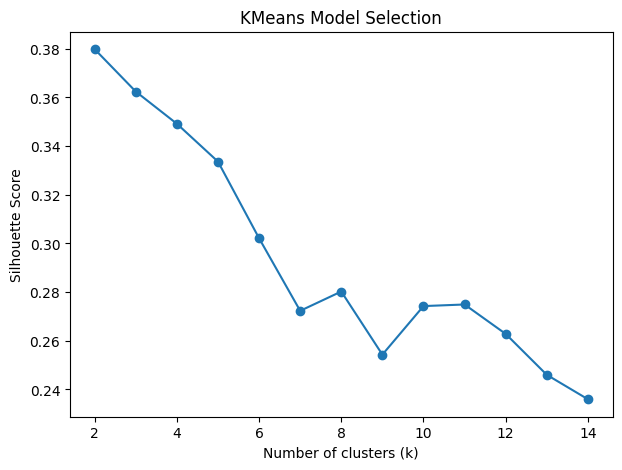

In [69]:
# Test different numbers of clusters using silhouette score
k_values = range(2, 15)
scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xf_scaled)
    score = silhouette_score(Xf_scaled, labels)
    scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

plt.figure(figsize=(7,5))
plt.plot(list(k_values), scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("KMeans Model Selection")
plt.show()

In [70]:
# Fit KMeans model with k = 2
# This gives the highest silhouette score and represents the strongest broad separation
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
# Assign cluster labels to each planet
data_ml["cluster_k2"] = km2.fit_predict(Xf_scaled)
# Show number of planets in each cluster
print(data_ml["cluster_k2"].value_counts().sort_index())
# Compare average physical properties of the two groups. Used to interpret what each cluster represents astrophysically
print(data_ml.groupby("cluster_k2")[
    ["pl_rade", "pl_bmasse", "density_proxy", "pl_orbsmax", "st_mass", "st_teff"]
].mean())

cluster_k2
0    439
1    704
Name: count, dtype: int64
              pl_rade   pl_bmasse  density_proxy  pl_orbsmax   st_mass  \
cluster_k2                                                               
0            2.495147   68.206482       4.803086    0.549991  0.759636   
1           12.462178  559.058201       0.376635    0.210424  1.096719   

                st_teff  
cluster_k2               
0           4790.503872  
1           5709.240483  


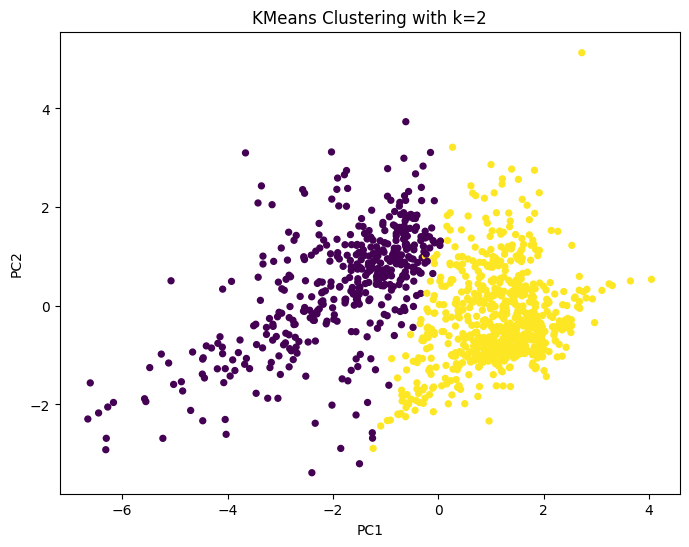

In [71]:
# Apply PCA for 2D visualization of the k = 2 clustering result
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(Xf_scaled)

data_ml["PC1"] = X_pca[:, 0]
data_ml["PC2"] = X_pca[:, 1]
# Plot the two-cluster solution in PCA space
plt.figure(figsize=(8,6))
plt.scatter(data_ml["PC1"], data_ml["PC2"], c=data_ml["cluster_k2"], s=18)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering with k=2")
plt.show()

In [72]:
# Fit an alternative KMeans model with k = 5
# Although silhouette score is lower than k = 2,
# this solution gives more detailed subclasses of exoplanets as professor mentioned that there are more than 3 types of planets
# So k = 5 would make it more physical
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
# Assign five-cluster labels
data_ml["cluster_k5"] = km5.fit_predict(Xf_scaled)
# Show number of planets in each cluster
print(data_ml["cluster_k5"].value_counts().sort_index())
# Compare average properties of the five clusters
print(data_ml.groupby("cluster_k5")[
    ["pl_rade", "pl_bmasse", "density_proxy", "pl_orbsmax", "st_mass", "st_teff"]
].mean())

cluster_k5
0    462
1    122
2    112
3    127
4    320
Name: count, dtype: int64
              pl_rade    pl_bmasse  density_proxy  pl_orbsmax   st_mass  \
cluster_k5                                                                
0           13.692784   432.830560       0.164009    0.059758  1.178219   
1           10.532562   458.976306       0.334021    0.040164  0.687711   
2            2.061363    63.769241      10.166938    1.833372  0.387258   
3            9.557246  1232.145616       5.683169    0.938292  1.107256   
4            2.540816    12.287948       1.239762    0.101799  0.916680   

                st_teff  
cluster_k5               
0           5969.045238  
1           4355.436066  
2           3466.116071  
3           5755.204724  
4           5356.745000  


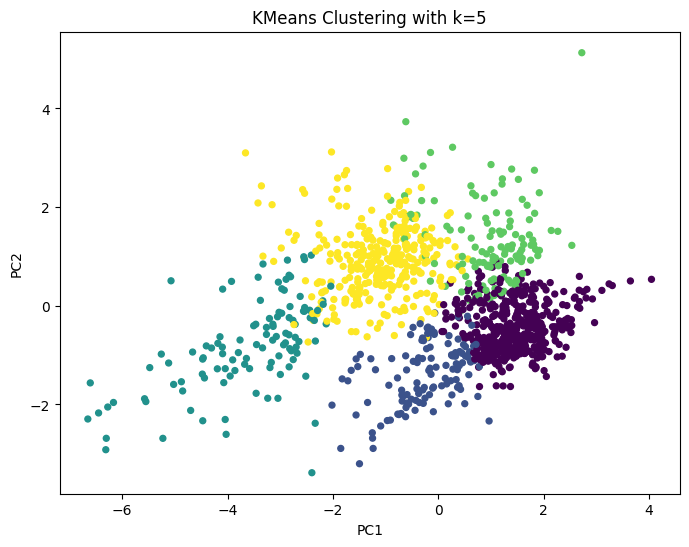

In [73]:
# Visualize the five-cluster solution using PCA coordinates
plt.figure(figsize=(8,6))
plt.scatter(data_ml["PC1"], data_ml["PC2"], c=data_ml["cluster_k5"], s=18)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering with k=5")
plt.show()

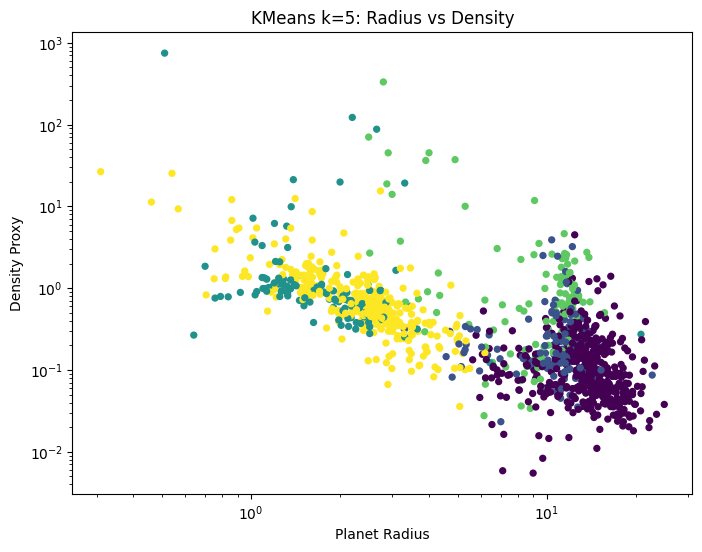

In [74]:
# Create a physically interpretable visualization of the k = 5 result
# x-axis = planet radius, y-axis = density proxy (mass / radius^3)
# Colors represent the five KMeans clusters
plt.figure(figsize=(8,6))
plt.scatter(
    data_ml["pl_rade"],
    data_ml["density_proxy"],
    c=data_ml["cluster_k5"],
    s=18
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Planet Radius")
plt.ylabel("Density Proxy")
plt.title("KMeans k=5: Radius vs Density")
plt.show()